# Assignment 2: Graph Visualization

## Data620

## Anthony Josue Roman

### Astrophysics Collaboration Network

For this assignment, I explored how astrophysics researchers are connected through co-authorship. This topic connects with my background in Astrophysics. I use the SNAP Astro Physics collaboration dataset. After that I selected a reproductcible connected subset of 150 authors, and calculate the graph metrics and visualize the results.

In [1]:
from pathlib import Path
from urllib.request import urlopen
from collections import deque
import random
import sys
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("Python:", sys.version.split()[0])
print("NetworkX:", nx.__version__)

Python: 3.14.6
NetworkX: 3.6.1


## 1. Dataset and Loading

The dataset page reports 18,772 authors and 198,110 undirected edges, which cover papers submitted to the arXiv's Astrophyiscs category from January 1993 through April 2003.

- A **node** represents an author, identified by a numeric ID.
- An **edge** means two authors co-authored at least one paper.
- A paper with mutliple authors produces connections between every pair of its authors.

I modeled the data as a simple, undirected, unweighted graph. Repeated pairs collaps into one edge, and self-loops are removed because this analysis concerns collaboration between the distinct authors. The edges do not indicate the number of papers written together. The Author IDs are not names, and this historical dataset does not describe current collaborations.

The `.txt.gz` file is a compressed text edge list. NetworkX reads it directly, skipping the comment lines that begin with `#`.

In [ ]:
DATA_URL = "https://snap.stanford.edu/data/ca-AstroPh.txt.gz"
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
data_file = data_dir / "ca-AstroPh.txt.gz"

if not data_file.exists():
    with urlopen(DATA_URL, timeout=120) as response:
        data_file.write_bytes(response.read())

full_graph = nx.read_edgelist(
    data_file, comments="#", nodetype=int, data=False, create_using=nx.Graph()
)
loaded_edges = full_graph.number_of_edges()
self_loops = list(nx.selfloop_edges(full_graph))
full_graph.remove_edges_from(self_loops)
components = list(nx.connected_components(full_graph))
largest_nodes = max(components, key=len)
largest_component = full_graph.subgraph(largest_nodes)

print(f"Authors: {full_graph.number_of_nodes():,}")
print(f"Unique undirected edges before removing self-loops: {loaded_edges:,}")
print(f"Self-loops removed: {len(self_loops):,}")
print(f"Edges used after cleaning: {full_graph.number_of_edges():,}")
print(f"Connected components: {len(components):,}")
print(f"Authors in largest component: {len(largest_nodes):,}")

Authors: 18,772
Unique undirected edges before removing self-loops: 198,110
Self-loops removed: 60
Edges used after cleaning: 198,050
Connected components: 290
Authors in largest component: 17,903


## 2. Select A Reproducible Connected Subset

The assignment permits a small subset of a large dataset, so I used 150 authors so the exact diameter and visualization will remain manageable.

I selected a starting author from the sorted IDs in the largest connected component using random seed 42. Then I used breadth-first search (BFS), visiting neighbors in sorted order, until I have 150 authors. The induced subgraph retains all original edges between the selected authors, not just the BFS discovery edges.

BFS ensures that each new author connects to an already selected author. This produces a connected sample, but it is a local neighborhoood sample, not a representative random sample of astrophysics. The starting location and node limit can change the results. All the subsequent metrics and visualizations refer only to this subset.

In [3]:
SAMPLE_SIZE = 150
SEED = 42
start_author = random.Random(SEED).choice(sorted(largest_component.nodes))
selected = [start_author]
seen = {start_author}
queue = deque([start_author])

while queue and len(selected) < SAMPLE_SIZE:
    current = queue.popleft()
    for neighbor in sorted(largest_component.neighbors(current)):
        if neighbor not in seen:
            seen.add(neighbor)
            selected.append(neighbor)
            queue.append(neighbor)
            if len(selected) == SAMPLE_SIZE:
                break

G = full_graph.subgraph(selected).copy()
assert G.number_of_nodes() == SAMPLE_SIZE
assert nx.is_connected(G)

subset_file = data_dir / "astrophysics_subset_edges.txt"
nx.write_edgelist(G, subset_file, data=False)
print(f"Starting author ID: {start_author}")
print(f"Subset: {G.number_of_nodes()} authors and {G.number_of_edges()} edges")
print(f"Connected: {nx.is_connected(G)}")
print(f"Subset saved to: {subset_file}")

Starting author ID: 27319
Subset: 150 authors and 2022 edges
Connected: True
Subset saved to: data/astrophysics_subset_edges.txt


## 3. Graph Metrics

**Diameter** is the maximum shortest-path distance between any two authors in the subset. It is not the longest possible route. Each edge counts as one collaboration link.

**Density** is the fraction of possible undirected edges that exist.

**Average degree** measures the average number of direct collaborators within the subset.

**Average shortest-path length** describes the typical separation.

**Average clustering coefficient** measures the average tendency for an author's neighbors to aalso be connected.

The complete dataset has multiple connected components, so a single finite diameter is not defined over all of its nodes. The selected graph is connected, and its diameter is calculated directly below, rather than copied from SNAP's dataset statistics.

In [4]:
n, m = G.number_of_nodes(), G.number_of_edges()
diameter = nx.diameter(G)
density = nx.density(G)
average_degree = sum(dict(G.degree()).values()) / n
average_path = nx.average_shortest_path_length(G)
clustering = nx.average_clustering(G)
summary = pd.DataFrame({
    "Metric": ["Authors", "Edges", "Diameter", "Density", "Average degree",
               "Average shortest-path length", "Average clustering coefficient"],
    "Subset value": [n, m, diameter, density, average_degree, average_path, clustering]
})
display(summary.round(4))

,Metric,Subset value
0,Authors,150.0000
1,Edges,2022.0000
2,Diameter,3.0000
3,Density,0.1809
4,Average degree,26.9600
5,Average shortest-path length,2.2041
6,Average clustering coefficient,0.8293


In [ ]:
display(Markdown(f"""## Interpretation
The selected graph above has **{n} authors** and **{m:,} collaboration links**. Its diameter is about **{diameter}**, so every pair can be connected by a shortest route of at most {diameter} links within this subset.

Its density is **{density:.3f}**, meaning **{density:.1%}** of possible author pairs are connected. Authors have an average of **{average_degree:.2f}** direct collaborators in the subset, and pairs are separated by an average shortest path of **{average_path:.2f}** links.

The average clustering coefficient is **{clustering:.3f}**. Coauthorship networks can contain tightly linked groups because a multi-author paper connects all of its coauthors. These metrics describe the selected neighborhood, not the full astrophysics community.
"""))

### Interpretation
The selected graph has **150 authors** and **2,022 collaboration links**. Its diameter is **3**, so every pair can be connected by a shortest route of at most 3 links within this subset.

Its density is **0.181**, meaning **18.1%** of possible author pairs are connected. Authors have an average of **26.96** direct collaborators in the subset, and pairs are separated by an average shortest path of **2.20** links.

The average clustering coefficient is **0.829**. Coauthorship networks can contain tightly linked groups because a multi-author paper connects all of its coauthors. These metrics describe the selected neighborhood, not the full astrophysics community.


## Degree Centrality

Degree centrality divides each author's number of neighbors by the numbe of other authors in the subset. The higher values indicate more direct collaborators within the sample. This does not meausre the citation impact, research quality, or the total career collaborations.

In [6]:
centrality = nx.degree_centrality(G)
node_metrics = pd.DataFrame([
    {"Author ID": node, "Degree": G.degree(node),
     "Degree centrality": centrality[node]} for node in G
]).sort_values(["Degree", "Author ID"], ascending=[False, True]).reset_index(drop=True)
display(node_metrics.head(10).round(4))
top = node_metrics.iloc[0]
display(Markdown(
    f"Author **{int(top['Author ID'])}** has the highest degree in the subset "
    f"(with ties ordered by ID): **{int(top['Degree'])}** neighbors and degree "
    f"centrality **{top['Degree centrality']:.3f}**. Authors outside the subset "
    "are excluded from this count."
))

,Author ID,Degree,Degree centrality
0,81251,105,0.7047
1,38670,81,0.5436
2,43160,79,0.5302
3,50808,79,0.5302
4,91586,79,0.5302
5,55837,77,0.5168
6,53213,73,0.4899
7,44612,70,0.4698
8,18314,69,0.4631
9,21718,68,0.4564


Author **81251** has the highest degree in the subset (with ties ordered by ID): **105** neighbors and degree centrality **0.705**. Authors outside the subset are excluded from this count.

## 4. Visualizations

### Collaboration Network

Larger and darker nodes have a higher degree. The label identifies the highest-ranked author by degree. The spring layout uses a fixed seed and places connected authors near each other. It is not a map, and the positions are not measured by social distances. To keep the figure readable, most of the author IDs are omitted, but every selected node and edge is plotted.

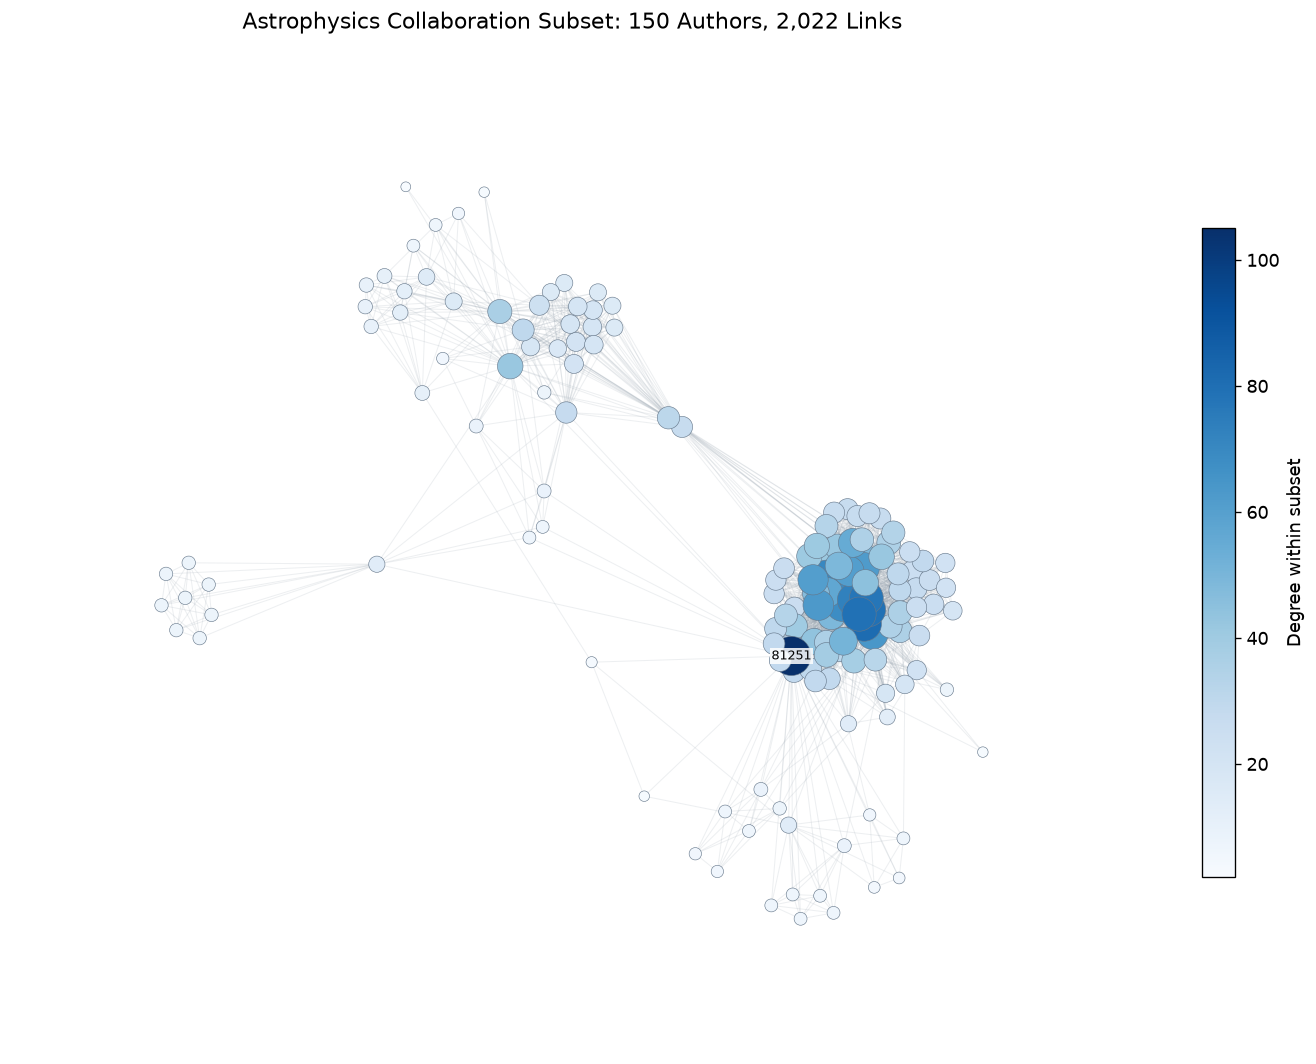

In [7]:
pos = nx.spring_layout(G, seed=SEED, weight=None, iterations=100)
nodes = sorted(G.nodes)
degrees = [G.degree(node) for node in nodes]
label_nodes = [int(x) for x in node_metrics.head(1)["Author ID"]]

def draw_network(ax, labels):
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#9CA8B3", alpha=0.18, width=0.6)
    artist = nx.draw_networkx_nodes(
        G, pos, ax=ax, nodelist=nodes,
        node_size=[25 + 5 * d for d in degrees], node_color=degrees,
        cmap=plt.cm.Blues, edgecolors="#65778A", linewidths=0.35
    )
    nx.draw_networkx_labels(
        G, pos, ax=ax, labels={node: str(node) for node in labels}, font_size=8,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1}
    )
    ax.margins(0.12)
    ax.axis("off")
    return artist

fig, ax = plt.subplots(figsize=(12, 9))
artist = draw_network(ax, label_nodes)
fig.colorbar(artist, ax=ax, shrink=0.65, label="Degree within subset")
ax.set_title(f"Astrophysics Collaboration Subset: {n} Authors, {m:,} Links", pad=15)
plt.tight_layout()
plt.show()

## Top Authors by Degree

The bar chart below gives an exact comparision of the ten highest degrees, supplementing the network. layout. An author can have a high degree because they contributed to a paper with many co-authors. These counts cannot distinguish one large-team paper from many separate collaborations.

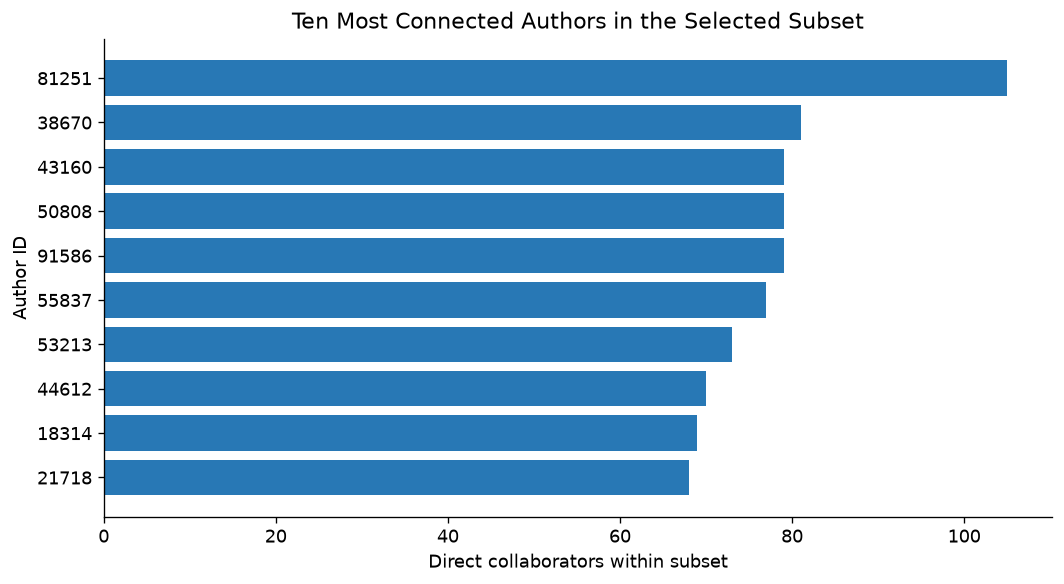

In [8]:
top_ten = node_metrics.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_ten["Author ID"].astype(str), top_ten["Degree"], color="#2878B5")
ax.set_xlabel("Direct collaborators within subset")
ax.set_ylabel("Author ID")
ax.set_title("Ten Most Connected Authors in the Selected Subset")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## One Shortest Path that Realizes the Diameter

I identified a pair of authors whose shortest-path distance equals the diameter and highlight one shortest route between them. Other pairs and routes may have the same distance. A shortest path in the full graph could be shorter if it uses authors excluded from the subset.

Author IDs along the path: 88 -> 81251 -> 98315 -> 3193
Path length: 3 edges


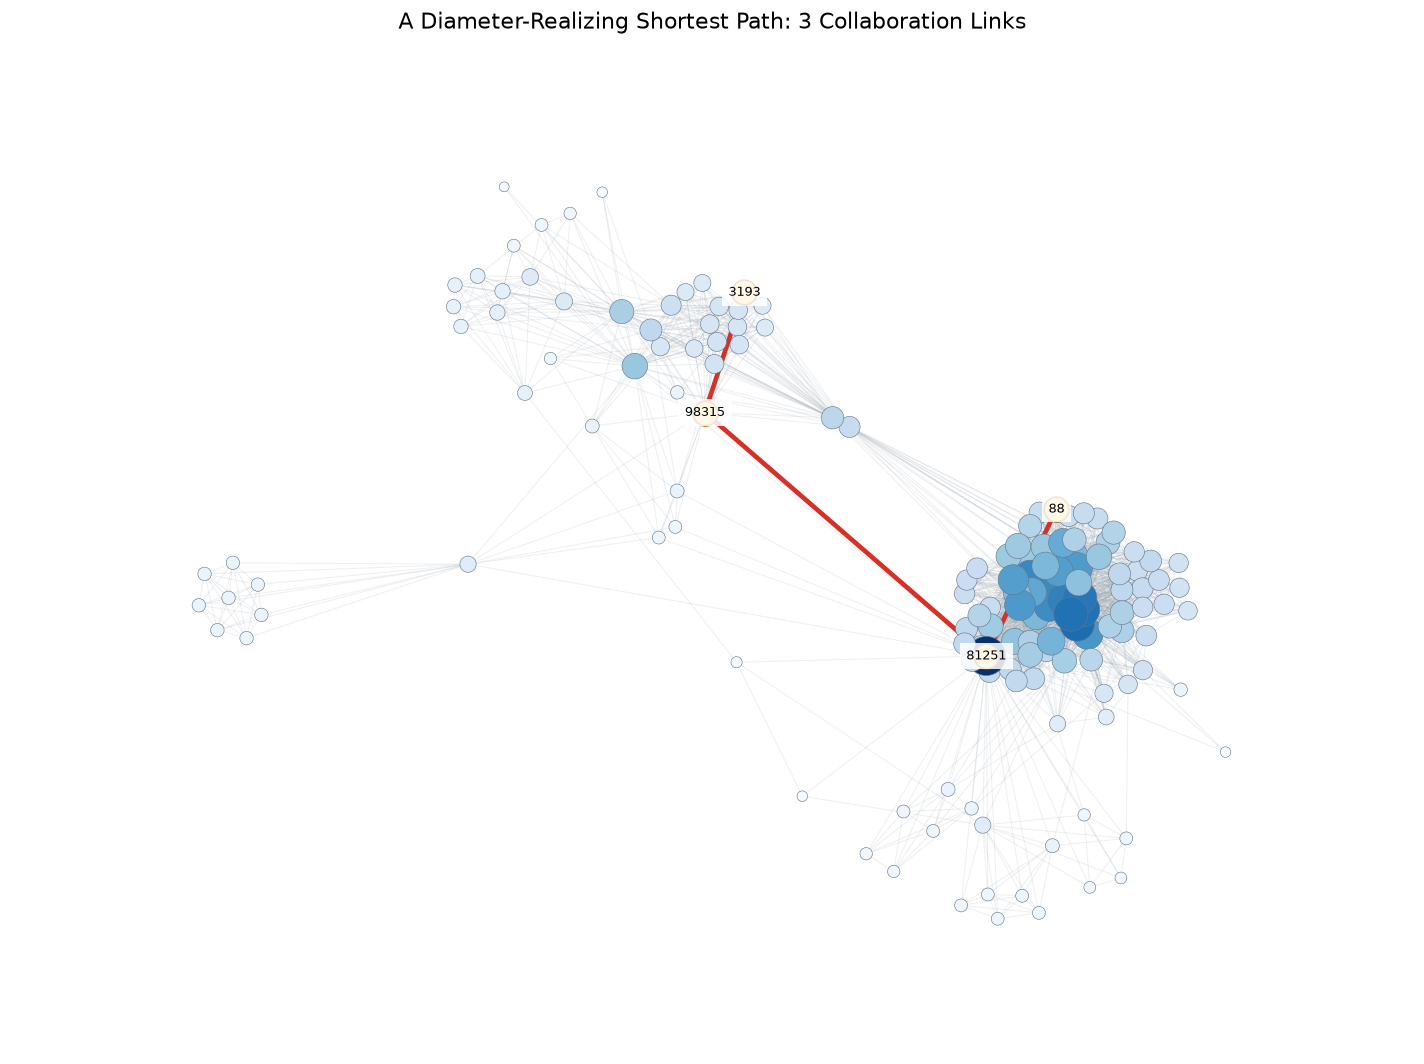

In [9]:
distances = dict(nx.all_pairs_shortest_path_length(G))
start, end = next((u, v) for u in sorted(G) for v in sorted(G)
                  if u < v and distances[u][v] == diameter)
path = nx.shortest_path(G, start, end)
path_edges = list(zip(path[:-1], path[1:]))
assert len(path_edges) == diameter
print("Author IDs along the path:", " -> ".join(map(str, path)))
print(f"Path length: {len(path_edges)} edges")

fig, ax = plt.subplots(figsize=(12, 9))
draw_network(ax, [])
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=path_edges, edge_color="#D73027", width=2.8)
nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=path, node_color="#FFD166",
                       edgecolors="#A34A00", node_size=220)
nx.draw_networkx_labels(G, pos, ax=ax, labels={u: str(u) for u in path}, font_size=8,
                        bbox={"facecolor":"white", "edgecolor":"none", "alpha":0.85})
ax.set_title(f"A Diameter-Realizing Shortest Path: {diameter} Collaboration Links", pad=15)
plt.tight_layout()
plt.show()

## 5. Conclusion and limitations

I used an observed astrophysics co-authorship network to study the connectons among a selected group of researchers. Diameter describes the largest shortest-path separation, while degree centrality highlights authors with many direct collaborators within this subset. The figures connect these numerical results to the network's structure.

The sample is a BFS neighborhood, thus it favors authors near the starting author and it does not represent the entire dataset. Restricting the graph can omit collaborators and change the distances and centrality rankings. Co-authorship alone does not measure relationship strength, citation impact, or information flow. Finally, this is a historical, aggregated network rather than a time-resolved account of how collaborations developed.

## References

- Stanford Network Analysis Project. (n.d.). *Astro Physics collaboration network*. https://snap.stanford.edu/data/ca-AstroPh.html

- Leskovec, J., Kleinberg, J., & Faloutsos, C. (2007). Graph evolution: Densification and shrinking diameters. *ACM Transactions on Knowledge Discovery from Data, 1*(1), Article 2. https://doi.org/10.1145/1217299.1217301